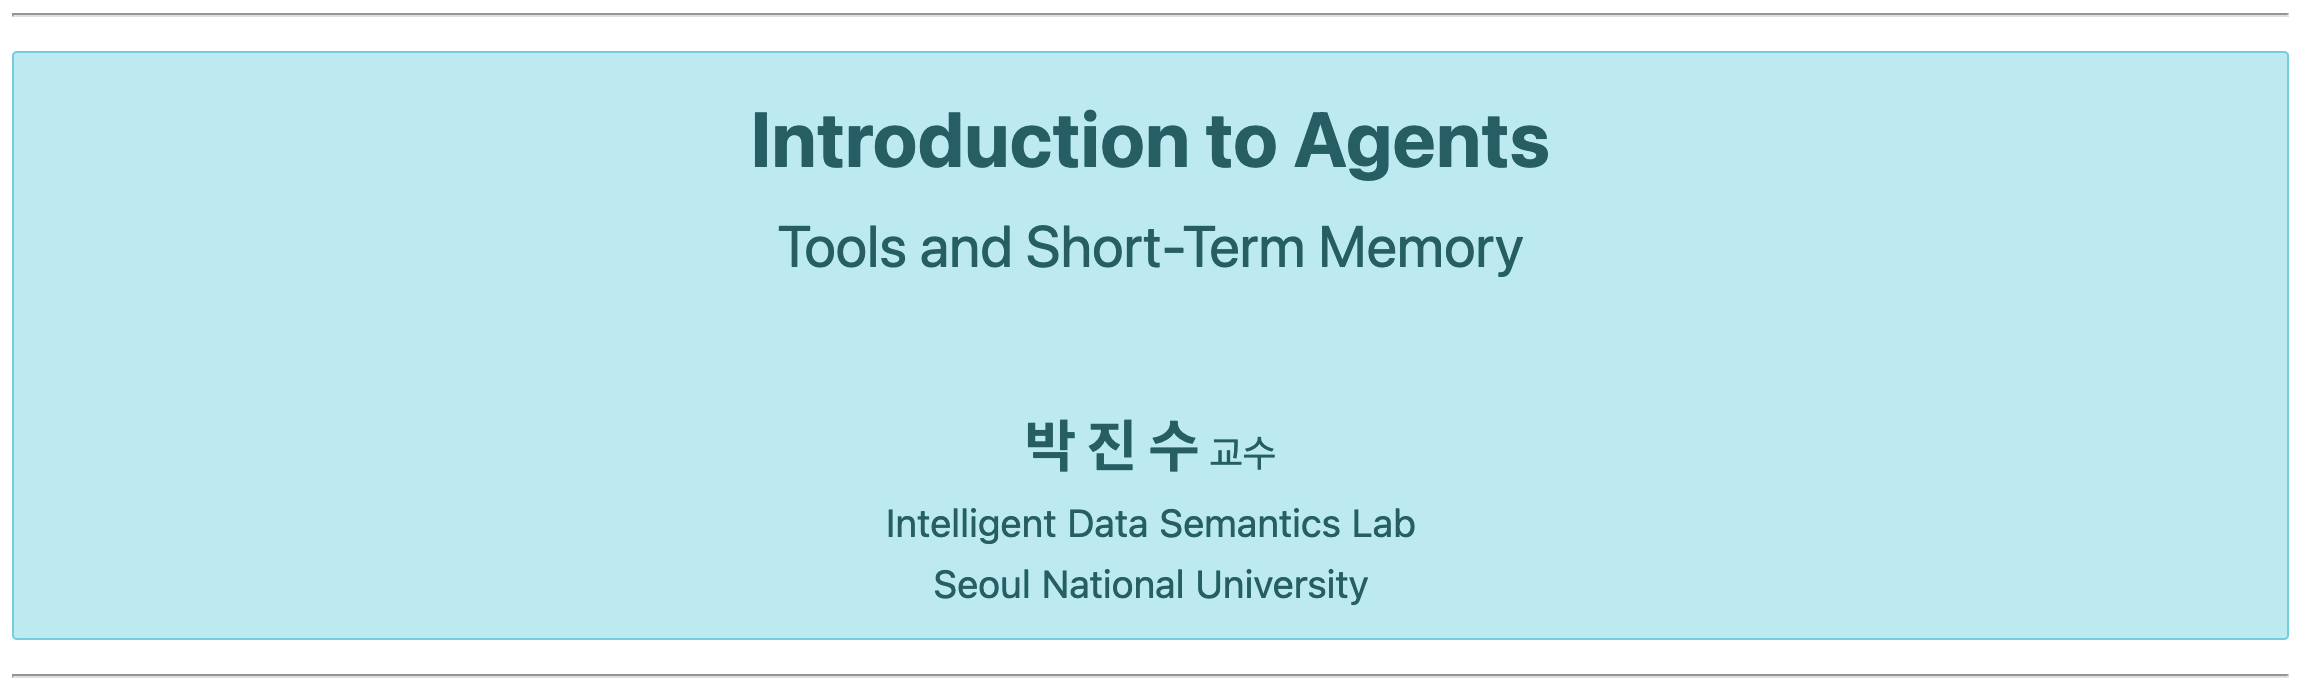

- - -    

- 본 자료는 강의를 위한 목적으로 LangChain이 제공하는 자료에 기반하여 제작했습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span><ul class="toc-item"><li><span><a href="#Setting-up-Tools-API" data-toc-modified-id="Setting-up-Tools-API-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Setting up Tools API</a></span></li><li><span><a href="#Setting-Up-Your-LLM-API" data-toc-modified-id="Setting-Up-Your-LLM-API-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Setting Up Your LLM API</a></span></li></ul></li><li><span><a href="#도우미-함수-가져오기" data-toc-modified-id="도우미-함수-가져오기-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>도우미 함수 가져오기</a></span></li><li><span><a href="#도구-정의" data-toc-modified-id="도구-정의-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>도구 정의</a></span><ul class="toc-item"><li><span><a href="#OpenWeatherMap" data-toc-modified-id="OpenWeatherMap-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>OpenWeatherMap</a></span></li><li><span><a href="#YouTubeSearchTool" data-toc-modified-id="YouTubeSearchTool-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>YouTubeSearchTool</a></span></li></ul></li><li><span><a href="#도구-사용-모델" data-toc-modified-id="도구-사용-모델-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>도구 사용 모델</a></span></li><li><span><a href="#에이전트" data-toc-modified-id="에이전트-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>에이전트</a></span><ul class="toc-item"><li><span><a href="#에이전트-구성" data-toc-modified-id="에이전트-구성-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>에이전트 구성</a></span></li><li><span><a href="#실행" data-toc-modified-id="실행-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>실행</a></span><ul class="toc-item"><li><span><a href="#메시지-호출" data-toc-modified-id="메시지-호출-5.2.1"><span class="toc-item-num">5.2.1&nbsp;&nbsp;</span>메시지 호출</a></span></li><li><span><a href="#메시지-스트리밍" data-toc-modified-id="메시지-스트리밍-5.2.2"><span class="toc-item-num">5.2.2&nbsp;&nbsp;</span>메시지 스트리밍</a></span></li></ul></li></ul></li><li><span><a href="#기억-추가" data-toc-modified-id="기억-추가-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>기억 추가</a></span></li><li><span><a href="#사용자-정의-도구-만들기" data-toc-modified-id="사용자-정의-도구-만들기-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>사용자 정의 도구 만들기</a></span></li><li><span><a href="#Lab:-여러-도구를-한번에-사용하는-질문" data-toc-modified-id="Lab:-여러-도구를-한번에-사용하는-질문-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Lab: 여러 도구를 한번에 사용하는 질문</a></span></li></ul></div>

# 패키지 설치 및 API 설정

## Setting up Tools API

- - -
먼저 OpenWeatherMap API 키를 얻기 위해 OpenWeatherMap에 가입해야 한다.
- OpenWeatherMap으로 이동하여 여기에서 API 키를 신청한다.
    + https://openweathermap.org/api/

그 다음 환경 변수를 설정해야 한다.
- **OPENWEATHERMAP_API_KEY** 환경 변수에 API 키를 저장한다.

마지막으로 pyowm 패키지를 설치한다.
- **python -m pip install pyowm**
- - -
설치 방법은 다음 자료를 참고해도 된다.
- https://drive.google.com/file/d/1RDaJKFILdfrHx-Tb8LeFA5iCjB2e4Mf3/view?usp=sharing
- - -

In [ ]:
!python -m pip install -qU pyowm youtube-search
print('--- Installation Completed', '-' * 55, '\n')

In [1]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

True

In [ ]:
# 방법 2 - API Key를 입력한다.
import os, getpass
os.environ['OPENWEATHERMAP_API_KEY'] = getpass.getpass('Enter Your OpenWeatherMap API Key: ')

In [ ]:
# 방법 3 - (caution) API 키 노출 주의
import os
os.environ['OPENWEATHERMAP_API_KEY'] = 'Your-OPENWEATHERMAP-API-Key'

## Setting Up Your LLM API

In [ ]:
!python -m pip install -qU python-dotenv pyowm youtube-search langgraph langchain langchain-community # YOUR LLM package HERE(e.g., openai anthropic google-genai groq mistralai ollama)
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [ ]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

In [ ]:
# 방법 3 (API Key 명칭 수정 후 사용) - (caution) API 키 노출 주의
import os
os.environ['?????_API_KEY'] = 'Your-LLM-API-Key'

# 도우미 함수 가져오기


In [2]:
# --- utils.py 다운로드
!gdown 1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi -O utils.py

Downloading...
From (original): https://drive.google.com/uc?id=1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi
From (redirected): https://drive.google.com/uc?id=1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi&confirm=t&uuid=770adc92-51b0-4bee-b477-07fd015b55ed
To: /Users/jinsoopark/Dropbox/_data/document/lecture/M2136.010900 generative ai for managerial decision-making/0_ipynb/utils.py
100%|██████████████████████████████████████| 36.6k/36.6k [00:00<00:00, 21.0MB/s]


# 도구 정의

## OpenWeatherMap

In [3]:
# --- 도구 정의
from langchain.tools import tool  
from langchain_community.utilities import OpenWeatherMapAPIWrapper

open_weather_map = OpenWeatherMapAPIWrapper()

@tool(
    'weather',
    description=(
        'Retrieve current weather information for a given city using the OpenWeatherMap API. '
        'Use this tool whenever the user requests weather conditions, temperature, humidity, '
        'or general meteorological information for any location.'
    )
)
def weather(city: str) -> str:
    try:
        result = open_weather_map.run(city)
        return result
    except Exception as err:
        raise ValueError(f'OpenWeatherMap API 오류: {err}')    

In [4]:
weather

StructuredTool(name='weather', description='Retrieve current weather information for a given city using the OpenWeatherMap API. Use this tool whenever the user requests weather conditions, temperature, humidity, or general meteorological information for any location.', args_schema=<class 'langchain_core.utils.pydantic.weather'>, func=<function weather at 0x108207240>)

## YouTubeSearchTool

In [6]:
# --- 도구 정의
from langchain_community.tools import YouTubeSearchTool

youtube = YouTubeSearchTool()

In [7]:
youtube

YouTubeSearchTool()

In [8]:
youtube.invoke('박진수 교수의 파이썬 강의 동영상')

"['https://www.youtube.com/watch?v=V8h-RocU9z4&pp=ygUu67CV7KeE7IiYIOq1kOyImOydmCDtjIzsnbTsjawg6rCV7J2YIOuPmeyYgeyDgQ%3D%3D', 'https://www.youtube.com/watch?v=Og7IGySRzo8&pp=ygUu67CV7KeE7IiYIOq1kOyImOydmCDtjIzsnbTsjawg6rCV7J2YIOuPmeyYgeyDgQ%3D%3D']"

# 도구 사용 모델 

- - -
LangChain에서 사용할 수 있는 모델 이름과 형식은 공식 문서에서 확인할 수 있다.
- https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model
- - -

In [ ]:
# --- 모델 초기화
from langchain.chat_models import init_chat_model

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
# --- 도구 구성

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

tools = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [11]:
tools

[YouTubeSearchTool(),
 StructuredTool(name='weather', description='Retrieve current weather information for a given city using the OpenWeatherMap API. Use this tool whenever the user requests weather conditions, temperature, humidity, or general meteorological information for any location.', args_schema=<class 'langchain_core.utils.pydantic.weather'>, func=<function weather at 0x108207240>)]

모델을 호출할 때 `.bind_tools`를 사용하여 모델을 생성하면 모델을 호출할 때마다 모델이 적절한 때에 필요한 도구를 호출할 수 있다.

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model_with_tools = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

모델이 도구를 호출하면 출력 결과의 **AIMessage.tool_calls** 속성에서 어떤 툴을 호출하는지 확인할 수 있다.

In [13]:
from langchain.messages import HumanMessage

result = model_with_tools.invoke(
    [HumanMessage('안녕하세요.')]
)
result

AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 225, 'total_tokens': 239, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.5-2026-04-23', 'system_fingerprint': None, 'id': 'chatcmpl-DmnuhHoCDDT0eE2gh9EBeRztwFj1S', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e8f7f-dad2-7b91-942c-ef7b715572bd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 225, 'output_tokens': 14, 'total_tokens': 239, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [14]:
from utils import extract_text

print(f'Content:   {extract_text(result)}')
print(f'ToolCalls: {result.tool_calls}')

Content:   안녕하세요! 무엇을 도와드릴까요?
ToolCalls: []


In [17]:
result = model_with_tools.invoke(
    [HumanMessage('파리의 현재 날씨는 어때요?')]
)
print(f'Content:   {extract_text(result)}')
print(f'ToolCalls: {result.tool_calls}')

Content:   
ToolCalls: [{'name': 'weather', 'args': {'city': 'Paris'}, 'id': 'call_uYeqP2gCXaSJ8pHIyXa7zJKn', 'type': 'tool_call'}]


In [32]:
result = model_with_tools.invoke(
    [HumanMessage('박진수 교수의 파이썬 강의 동영상')]
)
print(f'Content:   {extract_text(result)}')
print(f'ToolCalls: {result.tool_calls}')

Content:   박진수 교수의 파이썬 강의 동영상을 검색하겠습니다.
ToolCalls: [{'name': 'youtube_search', 'args': {'query': '박진수 교수 파이썬 강의, 10'}, 'id': 'toolu_01TVUCM4v8y2KZGHwCRWPPVi', 'type': 'tool_call'}]


# 에이전트 

## 에이전트 구성

In [ ]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

# --- 시스템 프롬프트
INSTRUCTION = '''You are an AI assistant that 
responds in the user’s language and provides 
explanations that are clear, accurate, concise, 
and helpful. 

Always follow the user’s intent and maintain 
a professional and consistent tone.

Please respond using plain text only. 
Do not use any Markdown formatting.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# --- 모델 초기화 
model = 

# --- 에이전트 구성
agent = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

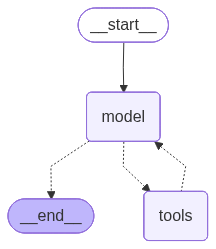

In [23]:
agent

## 실행 

### 메시지 호출

In [15]:
# --- 먼저 도구를 호출할 필요가 없을 때 어떻게 반응하는지 살펴본다.
from utils import extract_text

user_message = '안녕하세요, 홍길동입니다. 현재 파리에 있습니다. 방문할 만한 좋은 장소를 하나 추천해주세요.'
result = agent.invoke({'messages': [HumanMessage(user_message)]})
print(extract_text(result))

파리에 계시면 ‘오르세 미술관(Musée d’Orsay)’을 추천합니다.

1) 왜 가볼 만한가
- 인상파/후기인상파의 대표작을 한 번에 보기 좋습니다(모네, 르누아르, 드가, 반 고흐 등).
- 원래 기차역이었던 건물을 미술관으로 바꾼 곳이라 내부 공간(특히 큰 시계 창) 자체가 볼거리입니다.
- 루브르보다 동선이 비교적 덜 부담스러워 “하나만 가볼 곳”으로 만족도가 높은 편입니다.

2) 방문 팁(간단)
- 인기 시간대는 줄이 길 수 있으니 가능하면 온라인 예매를 권합니다.
- 내부의 큰 시계 창 쪽은 사진 포인트라 시간이 되면 꼭 들러보세요.

원하시면 지금 계신 위치(대략 어느 구/근처 역)와 선호(미술/야경/산책/쇼핑)를 알려주시면, 이동이 편한 “딱 한 곳”으로 더 맞춤 추천해드릴게요.


In [16]:
result['messages'][1].tool_calls

[]

In [17]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

안녕하세요, 홍길동입니다. 현재 파리에 있습니다. 방문할 만한 좋은 장소를 하나 추천해주세요.
================================== Ai Message ==================================

파리에 계시면 ‘오르세 미술관(Musée d’Orsay)’을 추천합니다.

1) 왜 가볼 만한가
- 인상파/후기인상파의 대표작을 한 번에 보기 좋습니다(모네, 르누아르, 드가, 반 고흐 등).
- 원래 기차역이었던 건물을 미술관으로 바꾼 곳이라 내부 공간(특히 큰 시계 창) 자체가 볼거리입니다.
- 루브르보다 동선이 비교적 덜 부담스러워 “하나만 가볼 곳”으로 만족도가 높은 편입니다.

2) 방문 팁(간단)
- 인기 시간대는 줄이 길 수 있으니 가능하면 온라인 예매를 권합니다.
- 내부의 큰 시계 창 쪽은 사진 포인트라 시간이 되면 꼭 들러보세요.

원하시면 지금 계신 위치(대략 어느 구/근처 역)와 선호(미술/야경/산책/쇼핑)를 알려주시면, 이동이 편한 “딱 한 곳”으로 더 맞춤 추천해드릴게요.


In [18]:
user_message = '내가 있는 곳의 날씨는 어떤가요?' 
result = agent.invoke({'messages': [HumanMessage(user_message)]})  
print(extract_text(result))

현재 계신 곳의 날씨를 알려면 위치 정보가 필요해요.

1) 지금 계신 도시/지역명을 알려주세요. (예: 서울, 부산 해운대, 대전 유성)
또는
2) 휴대폰/브라우저에서 표시된 위치(도시명)를 그대로 보내주세요.

도시명을 주시면 현재 기온, 체감, 습도, 바람, 강수 여부까지 바로 확인해드릴게요.


In [19]:
result['messages'][1].tool_calls

[]

In [20]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

내가 있는 곳의 날씨는 어떤가요?
================================== Ai Message ==================================

현재 계신 곳의 날씨를 알려면 위치 정보가 필요해요.

1) 지금 계신 도시/지역명을 알려주세요. (예: 서울, 부산 해운대, 대전 유성)
또는
2) 휴대폰/브라우저에서 표시된 위치(도시명)를 그대로 보내주세요.

도시명을 주시면 현재 기온, 체감, 습도, 바람, 강수 여부까지 바로 확인해드릴게요.


In [21]:
# --- 이제 도구를 호출해야 하는 예제에서 사용해 보자.
user_message = '파리의 현재 날씨는 어때요?'  
result = agent.invoke({'messages': [HumanMessage(user_message)]})  
print(extract_text(result))

현재 파리 날씨는 안개가 끼어 있습니다.  
기온은 약 8.0°C(체감 6.8°C)이고, 최고 8.4°C / 최저 6.8°C예요.  
습도는 97%로 매우 높고, 바람은 2.1 m/s 정도로 약하게 붑니다.


In [22]:
result['messages'][1].tool_calls

[{'name': 'weather',
  'args': {'city': 'Paris'},
  'id': 'call_qXdCUTt9dwp5ba6mT3p5Ek6n',
  'type': 'tool_call'}]

In [23]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

파리의 현재 날씨는 어때요?
================================== Ai Message ==================================
Tool Calls:
  weather (call_qXdCUTt9dwp5ba6mT3p5Ek6n)
 Call ID: call_qXdCUTt9dwp5ba6mT3p5Ek6n
  Args:
    city: Paris
================================= Tool Message =================================
Name: weather

In Paris, the current weather is as follows:
Detailed status: fog
Wind speed: 2.06 m/s, direction: 40°
Humidity: 97%
Temperature: 
  - Current: 7.98°C
  - High: 8.41°C
  - Low: 6.79°C
  - Feels like: 6.79°C
Rain: {}
Heat index: None
Cloud cover: 100%
================================== Ai Message ==================================

현재 파리 날씨는 안개가 끼어 있습니다.  
기온은 약 8.0°C(체감 6.8°C)이고, 최고 8.4°C / 최저 6.8°C예요.  
습도는 97%로 매우 높고, 바람은 2.1 m/s 정도로 약하게 붑니다.


### 메시지 스트리밍

In [24]:
# --- stream_mode='values'
user_message = '파리의 현재 날씨는 어때요?'  

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 스트리밍 청크 단위로 출력
            
# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

================================ Human Message =================================

파리의 현재 날씨는 어때요?
================================== Ai Message ==================================
Tool Calls:
  weather (call_soHQMfYsceq60jAcNPmjpoF6)
 Call ID: call_soHQMfYsceq60jAcNPmjpoF6
  Args:
    city: Paris
================================= Tool Message =================================
Name: weather

In Paris, the current weather is as follows:
Detailed status: fog
Wind speed: 2.06 m/s, direction: 40°
Humidity: 97%
Temperature: 
  - Current: 7.98°C
  - High: 8.41°C
  - Low: 6.79°C
  - Feels like: 6.79°C
Rain: {}
Heat index: None
Cloud cover: 100%
================================== Ai Message ==================================

현재 파리 날씨는 안개가 끼어 있고, 구름량은 100%입니다.
기온은 7.98°C(체감 6.79°C)이며, 최고 8.41°C / 최저 6.79°C로 예상됩니다.
습도는 97%이고, 바람은 2.06 m/s로 북동쪽(40°)에서 불고 있습니다.


In [25]:
# --- stream_mode='messages'
from utils import streaming_chat

user_message = '파리의 현재 날씨는 어때요?'  

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

            
# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

현재 파리 날씨는 안개가 끼어 있습니다.  
기온은 약 8.0°C(체감 6.8°C)이고, 최고 8.4°C / 최저 6.8°C입니다.  
습도는 97%로 매우 높고, 바람은 2.1m/s(약한 바람)입니다. 구름은 100%입니다.

In [26]:
# --- astream_events
user_message = '오늘 서울의 날씨는 어때요?'  

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

현재 서울 날씨는 맑음(쾌청)입니다.
- 기온: 5.76°C (최고 6.78°C / 최저 5.76°C)
- 체감기온: 2.46°C
- 습도: 36%
- 바람: 4.63 m/s, 서쪽(280°) 방향
- 구름: 0%

# 기억 추가

In [30]:
user_message = '안녕하세요. 나는 온톨로지입니다.'
result = agent.invoke({'messages': [HumanMessage(user_message)]})
print(extract_text(result))

안녕하세요, 온톨로지님. 만나서 반갑습니다.
어떤 도움을 드릴까요?


In [32]:
user_message = '내 이름이 뭐였는지 알려줄 수 있나요?'  
result = agent.invoke({'messages': [HumanMessage(user_message)]})
print(extract_text(result))

지금 대화에선 사용자의 이름 정보를 받은 적이 없어서 알 수 없어요.

이 채팅에서 제가 부를 이름을 알려주시면 그 이름으로 기억해서 이후에 그렇게 불러드릴게요.


In [ ]:
from langgraph.checkpoint.memory import InMemorySaver  # --- (new) ------------
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent


# --- 시스템 프롬프트
INSTRUCTION = '''You are an AI assistant that 
responds in the user’s language and provides 
explanations that are clear, accurate, concise, 
and helpful. 

Always follow the user’s intent and maintain 
a professional and consistent tone.

Please respond using plain text only. 
Do not use any Markdown formatting.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# --- 모델 초기화
model = 

# --- 단기 기억 구성 (short-term, in-memory)
memory = 

# --- 에이전트 구성
agent_with_memory = 
)

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

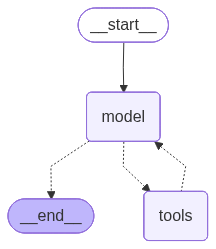

In [10]:
agent_with_memory

In [28]:
config = {'configurable': {'thread_id': 'user-1'}}

user_message = '안녕하세요. 나는 온톨로지입니다.'
result = agent_with_memory.invoke(
    {'messages': [HumanMessage(user_message)]},
    config=config
)
print(extract_text(result))

안녕하세요! 반갑습니다. 온톨로지라는 이름이신가요? 아니면 온톨로지(ontology)라는 개념에 대해 이야기하고 싶으신 건가요?

무엇을 도와드릴까요?


In [29]:
user_message = '내 이름이 뭐였는지 알려줄 수 있나요?'  
result = agent_with_memory.invoke(
    {'messages': [HumanMessage(user_message)]}, 
    config=config  
)
print(extract_text(result))

네, 방금 전에 자신을 "온톨로지"라고 소개하셨습니다. 

당신의 이름은 온톨로지입니다.


In [33]:
# --- 새로운 대화를 시작하려면 사용할 thread_id를 변경하기만 하면 된다. 
config = {'configurable': {'thread_id': 'user-2'}}

user_message = '내 이름이 뭐였는지 알려줄 수 있나요?'  
result = agent_with_memory.invoke(
    {'messages': [HumanMessage(user_message)]}, 
    config=config
)
print(extract_text(result))

죄송하지만, 저는 당신의 이름을 알지 못합니다. 우리의 대화에서 당신이 이름을 말씀해주신 적이 없고, 저는 이전 대화 기록에 접근할 수 없습니다.

만약 이름을 알려주시면, 이번 대화 동안에는 그 이름으로 불러드릴 수 있습니다. 어떻게 불러드리면 될까요?


In [32]:
# --- 이번에는 현재 시간을 물어보자.
import uuid

thread_id = uuid.uuid4()
config = {'configurable': {'thread_id': thread_id}}

user_message = '지금 정확한 시간이 어떻게 되나요?'  
result = agent_with_memory.invoke(
    {'messages': [HumanMessage(user_message)]}, 
    config=config  
)
print(extract_text(result))

죄송합니다. 저는 현재 정확한 실시간 시간을 직접 확인할 수 있는 기능이 없습니다.

정확한 현재 시간을 확인하시려면 다음 방법을 이용해 보세요:

1. 스마트폰이나 컴퓨터의 시계 확인
2. 인터넷 검색창에 "현재 시간" 검색
3. 네이버, 구글 등에서 시간 검색

다른 도움이 필요하신 것이 있으면 말씀해 주세요!


# 사용자 정의 도구 만들기

In [ ]:
# --- 도구 정의
from langchain.tools import tool
from datetime import datetime
from typing import Literal


@tool(
    'current_time',
    description=(
        'Return the current local time. '
        'Choose 12-hour (with AM/PM) or 24-hour format.'
    )
)
def current_time(clock: Literal['12h', '24h'] = '24h') -> str:

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 

In [24]:
print(current_time.name)
print(current_time.description)
print(current_time.args)

current_time
Return the current local time. Choose 12-hour (with AM/PM) or 24-hour format.
{'clock': {'default': '24h', 'description': "Time display style. 표시 방식. '24h'는 00–23시, '12h'는 AM/PM 포함.", 'enum': ['12h', '24h'], 'title': 'Clock', 'type': 'string'}}


In [4]:
current_time.invoke({'clock': '24h'})

'14:06:33'

In [5]:
current_time.invoke({'clock': '12h'})

'02:06:35PM'

In [ ]:
# --- 도구 구성

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

tools = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

# --- 시스템 프롬프트
INSTRUCTION = '''You are an AI assistant that 
responds in the user’s language and provides 
explanations that are clear, accurate, concise, 
and helpful. 

Always follow the user’s intent and maintain 
a professional and consistent tone.

Please respond using plain text only. 
Do not use any Markdown formatting.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# --- 모델 초기화
model = 

# --- 에이전트 구성
agent = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [27]:
user_message = '지금 정확한 시간이 어떻게 되나요?'  
result = agent.invoke({'messages': [HumanMessage(user_message)]})
print(extract_text(result))

현재 시간은 08:27:30 (24시간 형식)입니다.


In [28]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

지금 정확한 시간이 어떻게 되나요?
================================== Ai Message ==================================
Tool Calls:
  current_time (58f0accc-7eae-42fb-969e-404b4d03d3be)
 Call ID: 58f0accc-7eae-42fb-969e-404b4d03d3be
  Args:
    clock: 24h
================================= Tool Message =================================
Name: current_time

08:27:30
================================== Ai Message ==================================

현재 시간은 08:27:30 (24시간 형식)입니다.


In [39]:
user_message = '지금 정확한 시간을 오전/오후 포함해서 어떻게 되나요?'  
result = agent.invoke({'messages': [HumanMessage(user_message)]})
print(extract_text(result))

현재 시간은 오후 3시 36분 20초입니다.


In [40]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

지금 정확한 시간을 오전/오후 포함해서 어떻게 되나요?
================================== Ai Message ==================================
Tool Calls:
  current_time (7965fec2-1aad-4aa8-94a5-7d0eb8ad64b5)
 Call ID: 7965fec2-1aad-4aa8-94a5-7d0eb8ad64b5
  Args:
    clock: 12h
================================= Tool Message =================================
Name: current_time

03:36:20PM
================================== Ai Message ==================================

현재 시간은 오후 3시 36분 20초입니다.


# Lab: 여러 도구를 한번에 사용하는 질문

에이전트를 사용하면 도구를 임의로 많이 사용해야 하는 질문을 할 수 있다.

- - -
**목표**: 복잡한 질문에 대한 다중 도구 호출(계산기 여러 번, 날씨 조회 등)
- **`calculator` 도구를 구현**하고, 실습 노트북의 **여러 도구를 한번에 사용하는 질문** Lab 섹션을 완성한다. 에이전트가 여러 도구를 순차적으로 사용하여 복잡한 질문에 올바르게 응답하는지 확인한다.

**요구사항**
1. **`calculator` 도구를 구현한다.** 두 정수에 대한 산술 연산(덧셈, 뺄셈, 곱셈, 나눗셈, 거듭제곱)을 수행하는 `calculator` 도구를 정의한다.
2. 실습 노트북의 해당 섹션에서 도구 목록(`tools`)에 calculator를 포함하고, 에이전트 구성을 완성한다.
3. 아래 **최소 테스트 질문**들을 에이전트에 입력하고, 실행 결과(응답 텍스트 또는 `messages` 출력)를 노트북에 남긴다.
4. 위 예시 외에 **2개 이상**의 추가 질문을 작성하여 테스트하고, 그 질문과 결과를 노트북에 기록한다. (예: 계산기만 여러 번 사용하는 질문, 날씨, 시간, YouTube 등 서로 다른 도구를 섞어 쓰는 질문)


**최소 테스트 질문 (실습에서 사용한 예시)**  
다음 질문들은 반드시 테스트한다.

1. **'3에 5제곱을 취하고 그것에 12와 3의 합을 곱한 다음 전체 결과를 제곱한다.'**
2. **'현재 여기 시간과 파리 날씨 알려주세요.'**
3. **'오늘 서울 날씨가 어때요? 날씨 좋으면 볼 만한 야외 활동 영상 하나 검색해주세요.'**

**제출 안내**        
- 제출 파일은 `.ipynb` 노트북 파일이다.
- 기존 실습 코드 아래에 과제 코드(테스트 셀, 추가 질문 및 결과)를 추가하여 제출한다.
- 코드를 모르는 사람도 이해할 수 있도록 코드에 친절하고 상세한 주석을 포함한다.

<details>
<summary><b>클릭하여 💡힌트 보기</b></summary>

- 실습에서 사용한 LangChain의 `@tool` 데코레이터로 함수를 감싸 `calculator`를 정의하면, 이 노트북의 다른 도구(`weather`, `youtube` 등)와 같은 방식으로 `tools`에 등록할 수 있다.
- `calculator` 도구는 `add`, `subtract`, `multiply`, `divide`, `exponentiate` 연산을 지원한다.
- `messages`를 순회하며 `pretty_print()`를 호출하면 각 도구 호출과 결과를 단계별로 확인할 수 있다.

</details>

- - -

In [ ]:
# YOUR CODE HERE

In [44]:
# YOUR CODE HERE

================================ Human Message =================================

3에 5제곱을 취하고 그것에 12와 3의 합을 곱한 다음 전체 결과를 제곱한다.
================================== Ai Message ==================================

[]
Tool Calls:
  calculator (a2e25cf0-c0f9-4c12-b008-19c8df1725cc)
 Call ID: a2e25cf0-c0f9-4c12-b008-19c8df1725cc
  Args:
    first: 3
    operation: exponentiate
    second: 5
  calculator (d86fb7d5-a51e-4d8f-882e-2f96a3b2550b)
 Call ID: d86fb7d5-a51e-4d8f-882e-2f96a3b2550b
  Args:
    first: 12
    operation: add
    second: 3
================================= Tool Message =================================
Name: calculator

243
================================= Tool Message =================================
Name: calculator

15
================================== Ai Message ==================================

[]
Tool Calls:
  calculator (cf8cab90-fe3b-4e95-b08d-83900c732a92)
 Call ID: cf8cab90-fe3b-4e95-b08d-83900c732a92
  Args:
    operation: multiply
    second: 15
    first: 2

In [42]:
# YOUR CODE HERE

================================ Human Message =================================

현재 여기 시간과 파리 날씨 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  current_time (b71df039-5d05-4d91-bff4-75d2bce8c5af)
 Call ID: b71df039-5d05-4d91-bff4-75d2bce8c5af
  Args:
    clock: 24h
================================= Tool Message =================================
Name: current_time

08:41:59
================================== Ai Message ==================================
Tool Calls:
  weather (7a1481e0-7fea-4a4b-a96d-72180bcdae63)
 Call ID: 7a1481e0-7fea-4a4b-a96d-72180bcdae63
  Args:
    city: Paris
================================= Tool Message =================================
Name: weather

In Paris, the current weather is as follows:
Detailed status: clear sky
Wind speed: 4.63 m/s, direction: 210°
Humidity: 70%
Temperature: 
  - Current: 14.1°C
  - High: 14.88°C
  - Low: 13.1°C
  - Feels like: 13.39°C
Rain: {}
Heat index: None
Cloud cover: 0%
=

In [50]:
# YOUR CODE HERE

================================ Human Message =================================

오늘 서울 날씨가 어때요? 날씨 좋으면 볼 만한 야외 활동 영상 하나 검색해주세요.
================================== Ai Message ==================================
Tool Calls:
  weather (b1f926b7-7054-4a16-860e-f03353216de4)
 Call ID: b1f926b7-7054-4a16-860e-f03353216de4
  Args:
    city: Seoul
================================= Tool Message =================================
Name: weather

In Seoul, the current weather is as follows:
Detailed status: clear sky
Wind speed: 3.6 m/s, direction: 220°
Humidity: 39%
Temperature: 
  - Current: 15.76°C
  - High: 16.78°C
  - Low: 15.76°C
  - Feels like: 14.41°C
Rain: {}
Heat index: None
Cloud cover: 0%
================================== Ai Message ==================================
Tool Calls:
  youtube_search (de2feadb-ea70-4fac-8a7c-4f3fdbb34bfa)
 Call ID: de2feadb-ea70-4fac-8a7c-4f3fdbb34bfa
  Args:
    query: 야외 활동,1
================================= Tool Message =================================

In [51]:
# --- stream_mode='messages'
user_message = '오늘 서울 날씨가 어때요? 날씨 좋으면 볼 만한 야외 활동 영상 하나 검색해주세요.'  
# YOUR CODE HERE

현재 서울의 날씨는 구름 없이 맑은 상태(Clear sky)입니다. 기온은 약 5.8°C(체감 온도 2.7°C)이며, 습도는 33%, 바람은 초속 4.1m 정도로 불고 있습니다. 

다소 쌀쌀할 수 있지만 하늘이 맑아 따뜻하게 입으신다면 야외 활동을 즐기기에 좋은 날씨입니다! 

요청하신 야외 활동 관련 추천 영상도 하나 찾아드렸습니다. 시청해 보시고 즐거운 시간 보내시길 바랍니다.
👉 https://www.youtube.com/watch?v=4yI-pEs8fWM

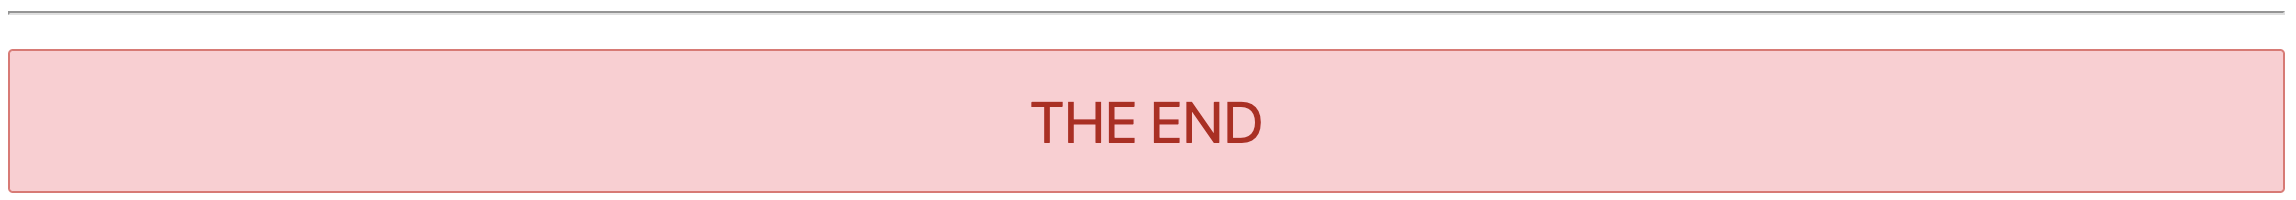